In [80]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time

In [81]:
'''
Authenticate
Authenticates your credentials and creates a client.
'''
subscription_key = os.environ["VISION_KEY"]
endpoint = os.environ["VISION_ENDPOINT"]
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
'''
END - Authenticate
'''

'\nEND - Authenticate\n'

In [82]:
# 1. Ocr result function
def get_ocr_result(image_path, language="en"):
    img = open(image_path, "rb")
    read_response = computervision_client.read_in_stream(
        image=img,
        mode="Printed",
        raw=True,
        language=language
    )
    operation_id = read_response.headers['Operation-Location'].split('/')[-1]
    while True:
        read_result = computervision_client.get_read_result(operation_id)
        if read_result.status not in ['notStarted', 'running']:
            break
        time.sleep(1)
    return read_result

In [83]:
# 1. ocr to text function
def get_ocr_text(image_path, language="en"):
    read_result = get_ocr_result(image_path, language)
    text = ""
    if read_result.status == OperationStatusCodes.succeeded:
        for page in read_result.analyze_result.read_results:
            for line in page.lines:
                text += line.text + " "
    # remove the last space
    return text.strip()

# in romanian
print(get_ocr_text("ocr.png",language="en"))

Optical Character Optical Character Recognition Recognition


In [85]:
# 1. char error rate using Hamming distance
def hamming_distance(str1, str2):
    if len(str1) != len(str2):
        raise ValueError("Strings must be of the same length")
    distance=sum(1 for a, b in zip(str1, str2) if a != b)
    return distance

def char_error_rate(actual, predicted):
    if len(actual) == 0:
        return 0.0 if len(predicted) == 0 else 1.0
    distance = hamming_distance(actual, predicted)
    return distance / len(actual)

In [86]:
# 1. run ocr cer
images=["test1.png","ocr.png","test2.jpeg"]
predicted=["Google Cloud Platform","Optical Character Optical Character Recognition Recognition", "Succes în rezolvarea tEMELOR la LABORA toarele de Inteligență Artificială!"]
actual=[get_ocr_text(img) for img in images]
for i in range(len(images)):
    print(f"Image: {images[i]}")
    print(f"Predicted: {predicted[i]}")
    print(f"Actual: {actual[i]}")
    print(f"CER using Hamming: {char_error_rate(actual[i], predicted[i])}")

Image: test1.png
Predicted: Google Cloud Platform
Actual: Google Cloud Platform
CER using Hamming: 0.0
Image: ocr.png
Predicted: Optical Character Optical Character Recognition Recognition
Actual: Optical Character Optical Character Recognition Recognition
CER using Hamming: 0.0
Image: test2.jpeg
Predicted: Succes în rezolvarea tEMELOR la LABORA toarele de Inteligență Artificială!
Actual: Lucces in resolvarea TEMELOR la LABORA toarele de Inteligenta Artificialà!
CER using Hamming: 0.0945945945945946


In [87]:
# 1. word error rate using Levenshtein distance
def levenshtein_distance(str1: str, str2: str) -> int:
    if len(str1) < len(str2):
        str1, str2 = str2, str1
    if len(str2) == 0:
        return len(str1)
    previous_row = list(range(len(str2) + 1))
    for i, c1 in enumerate(str1, start=1):
        current_row = [i]
        for j, c2 in enumerate(str2, start=1):
            insertion = previous_row[j] + 1
            deletion = current_row[j - 1] + 1
            substitution = previous_row[j - 1] + (c1 != c2)
            current_row.append(min(insertion, deletion, substitution))
        previous_row = current_row
    return previous_row[-1]

def word_error_rate(actual, predicted):
    actual_words = actual.split()
    predicted_words = predicted.split()
    if len(actual_words) == 0:
        return 0.0 if len(predicted_words) == 0 else 1.0
    distance = levenshtein_distance(" ".join(actual_words), " ".join(predicted_words))
    return distance / len(actual_words)

In [88]:
# 1. run ocr wer
for i in range(len(images)):
    print(f"Image: {images[i]}")
    print(f"Predicted: {predicted[i]}")
    print(f"Actual: {actual[i]}")
    print(f"WER using Levenshtein: {word_error_rate(actual[i], predicted[i])}")

Image: test1.png
Predicted: Google Cloud Platform
Actual: Google Cloud Platform
WER using Levenshtein: 0.0
Image: ocr.png
Predicted: Optical Character Optical Character Recognition Recognition
Actual: Optical Character Optical Character Recognition Recognition
WER using Levenshtein: 0.0
Image: test2.jpeg
Predicted: Succes în rezolvarea tEMELOR la LABORA toarele de Inteligență Artificială!
Actual: Lucces in resolvarea TEMELOR la LABORA toarele de Inteligenta Artificialà!
WER using Levenshtein: 0.7


In [89]:
# 2. get ocr location
def get_ocr_location(image_path, language="en"):
    read_result = get_ocr_result(image_path, language)
    locations = []
    if read_result.status == OperationStatusCodes.succeeded:
        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                x1,y1,x2,y2,x3,y3,x4,y4=line.bounding_box
                locations.append([x1,y1,x3,y3])
    return locations

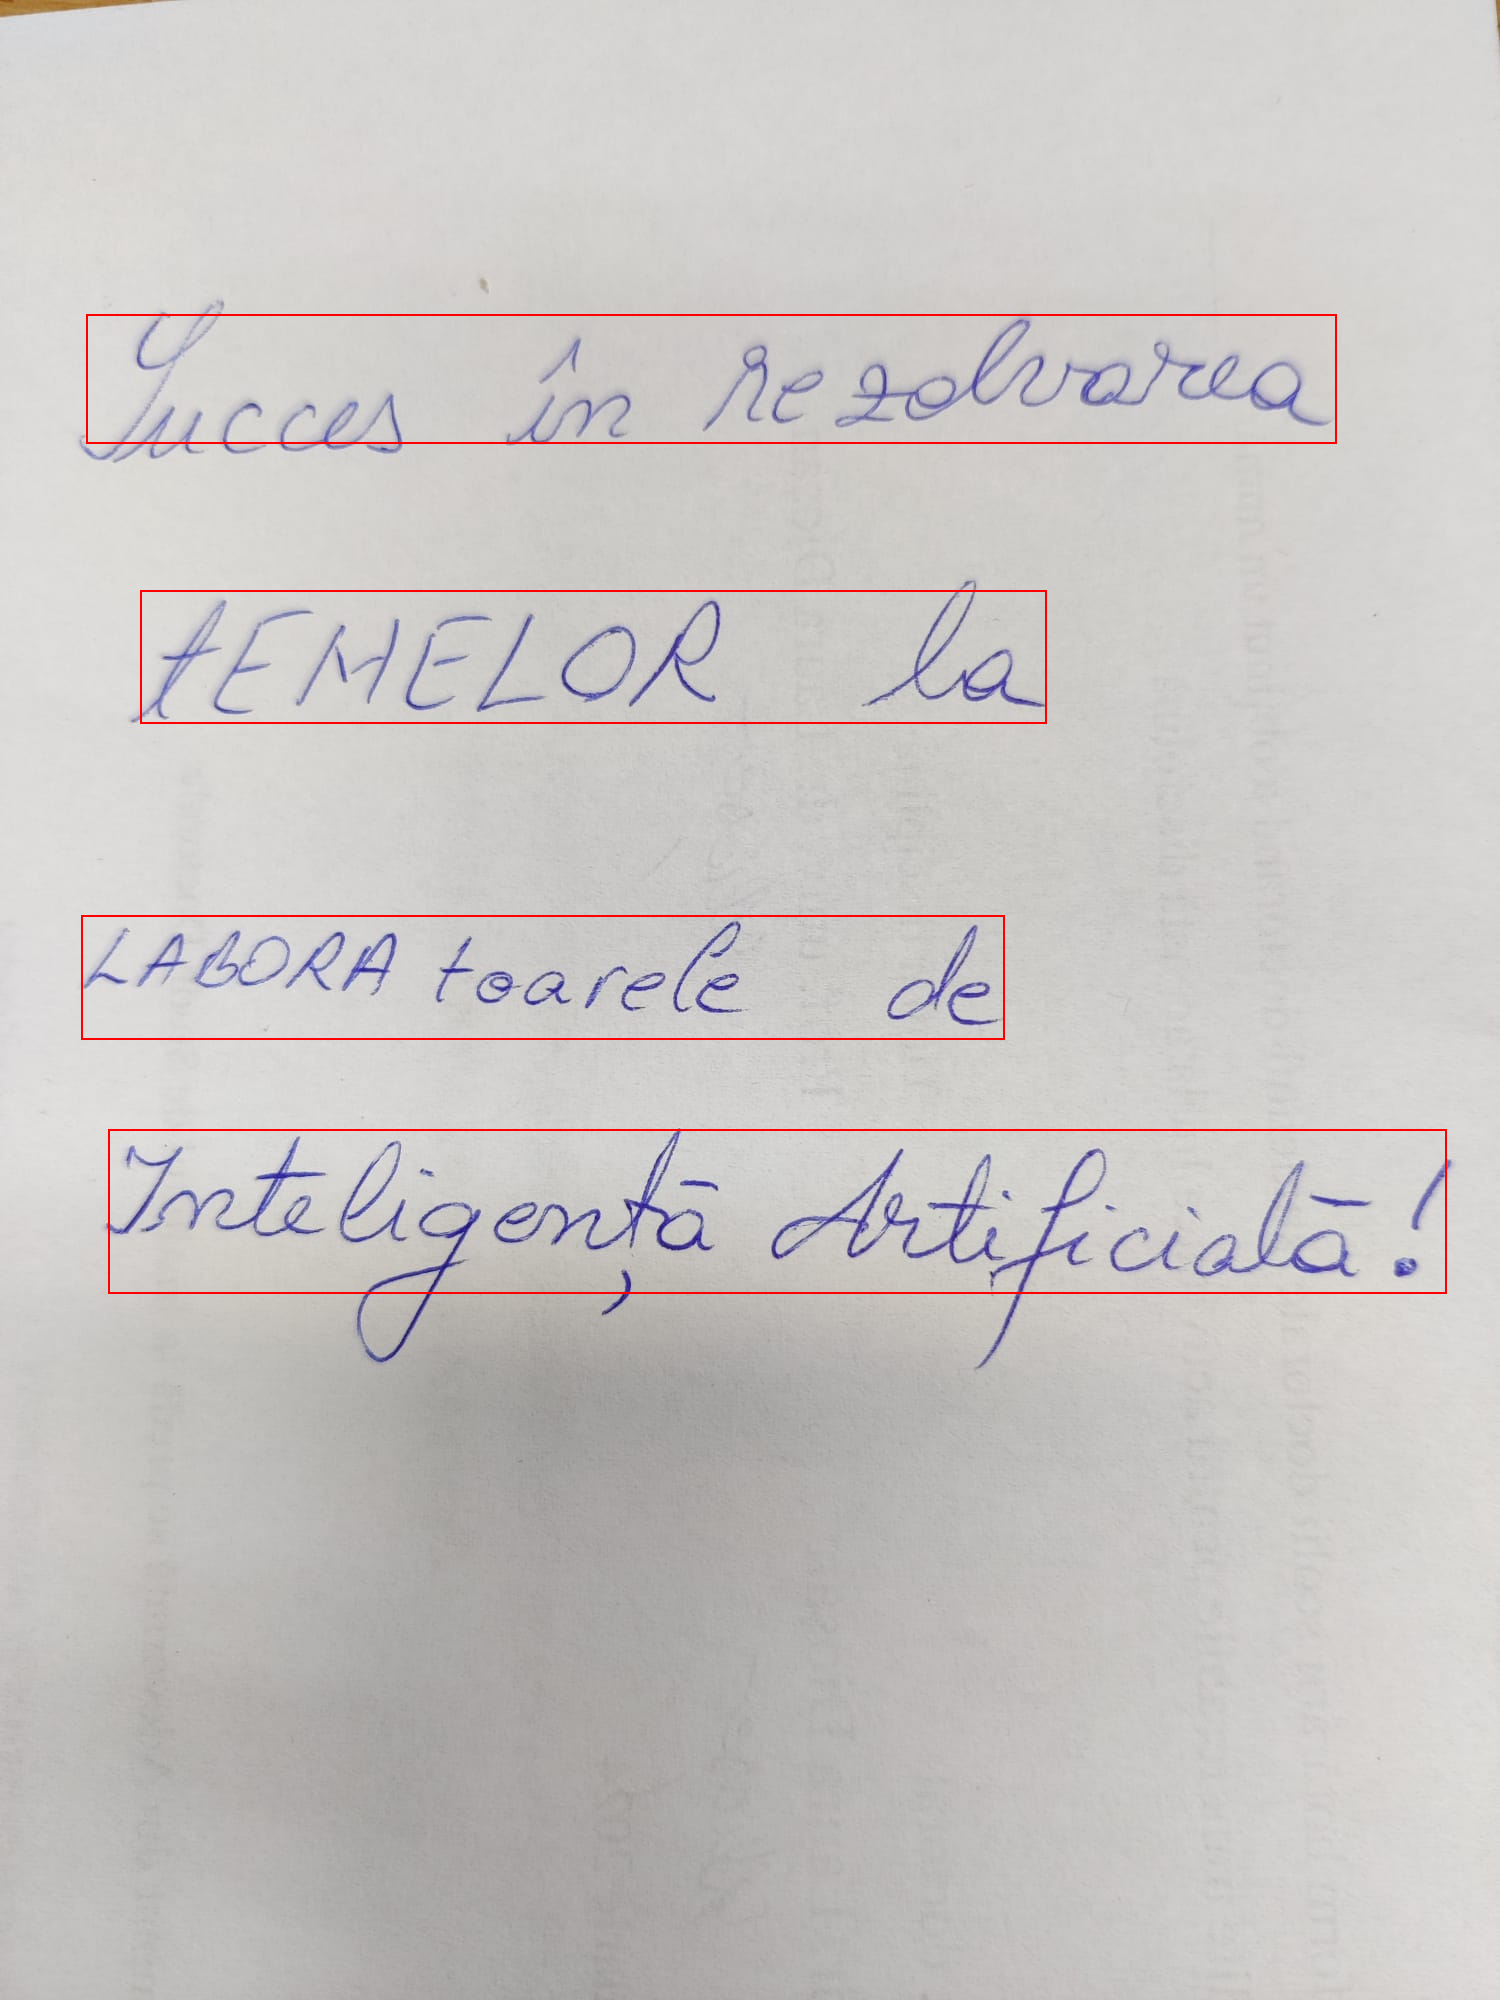

In [93]:
from PIL import ImageDraw


# 2. draw ocr location
def draw_ocr_location(image_path, language="en"):
    locations=get_ocr_location(image_path, language)
    img=Image.open(image_path)
    draw=ImageDraw.Draw(img)
    for loc in locations:
        draw.rectangle(loc, outline="red", width=2)
    display(img)

draw_ocr_location(images[2])

In [101]:
# 2. IOU function

def calculate_iou(box1,box2):
    #iou= i/union else 0
    #calculam intersectia
    x1=max(box1[0],box2[0])
    y1=max(box1[1],box2[1])
    x2=min(box1[2],box2[2])
    y2=min(box1[3],box2[3])
    area_of_intersection=max(0,x2-x1+1)*max(0,y2-y1+1)
    #union=area1+are2-inters
    area_box1=(box1[2]-box1[0]+1)*(box1[3]-box1[1]+1)
    area_box2=(box2[2]-box2[0]+1)*(box2[3]-box2[1]+1)
    union=area_box1+area_box2-area_of_intersection
    #calculam iou
    return area_of_intersection/union if union>0 else 0

In [102]:
# 2. quality of ocr location using IOU
def evaluate_ocr_localization(image_path, actual_boxes, language="en"):
    pred_boxes=get_ocr_location(image_path, language)
    ious=[]
    matched_pred=set()
    for actual in actual_boxes:
        best_iou=0
        best_idx=-1
        for idx, pred in enumerate(pred_boxes):
            if idx in matched_pred:
                continue
            iou=calculate_iou(actual, pred)
            if iou>best_iou:
                best_iou=iou
                best_idx=idx
        if best_idx>=0:
            matched_pred.add(best_idx)
            ious.append(round(best_iou,4))
        else:
            ious.append(0.0)

    extra_detections=len(pred_boxes)-len(matched_pred)
    for _ in range(extra_detections):
        ious.append(0.0)

    mean_iou=sum(ious)/len(ious) if ious else 0.0

    return mean_iou

In [105]:
# 2. run ocr localization evaluation
actual_loc=[[[177,44,417,97],[234,112,350,151]],[[64,300,1345,469],[119,580,1065,726],[81,908,1025,1031],[106,1128,1467,1317]]]

images.remove(images[1])

for i in range(len(images)):
    print(f"Image: {images[i]}")
    print(f"Actual Boxes: {actual_loc[i]}")
    print(f"Mean IOU: {evaluate_ocr_localization(images[i], actual_loc[i])}")

Image: test1.png
Actual Boxes: [[177, 44, 417, 97], [234, 112, 350, 151]]
Mean IOU: 0.84585
Image: test2.jpeg
Actual Boxes: [[64, 300, 1345, 469], [119, 580, 1065, 726], [81, 908, 1025, 1031], [106, 1128, 1467, 1317]]
Mean IOU: 0.835225


In [106]:
# 3. posible improvements

# a. pre-procesare imagine -
#                  - transformare in grayscale
#                  - aplicare filtru de netezire pentru reducerea zgomotului
#                  - ajustare inclinare pentru a corecta textul distorsionat
#                  - rescalare pentru a imbunatati claritatea textului

# b. post-procesare text -
#                  - corectie dictionar pentru a corecta erorile comune de recunoastere
#                  - regex pentru a extrage doar informatiile relevante (ex: numere de telefon, adrese de email)

# c. imbunatatire claritate imagine -
#                  - imbunatatirea iluminarii pentru a face textul mai vizibil
#                  - rezolutie superioara pentru a captura mai multe detalii ale textului